# Part 4 - Outlier Detection and Removal

**Individual Preprocessing Technique:** Outlier Detection / Removal  
**Member:** Hansani J.A.T.H. 
**IT Number:** IT25300345
**Dataset:** Adult Income Dataset (Census Income)

### Objective
Identify unusually extreme values in `capital.gain`, `capital.loss`, and `hours.per.week`, visualize them with boxplots, remove only the most extreme upper-tail observations, and verify the cleaned dataset.

## Why this step is needed

Outliers are observations that are unusually far from the main distribution. They can strongly affect statistical summaries and some machine-learning algorithms.

For this dataset, `capital.gain` and `capital.loss` are highly right-skewed and mostly contain zero values. `hours.per.week` also has a long upper tail. Therefore, a normal IQR rule would be too aggressive for these variables.

**Important:** an extreme value is not automatically a data error. The aim here is to remove only clearly extreme upper-tail observations while keeping realistic records.

## Common Pipeline Prerequisites
This section follows the same project conventions used by the other notebooks. The raw Adult dataset is loaded, text whitespace is standardized, `?` is converted to `NaN`, and the 24 exact duplicate rows identified by the duplicate-removal member are removed.

These are prerequisites only; the individual contribution starts with the outlier analysis below.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project paths
DATA_RAW_PATH = Path('../data/raw/adult.csv')
OUTPUT_FIGURES_DIR = (Path.cwd().parent / 'results' / 'eda_visualizations').resolve()
OUTPUT_RESULTS_DIR = Path('../results/outputs')
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Load raw data
df_raw = pd.read_csv(DATA_RAW_PATH)
df = df_raw.copy()

# Standardize strings and convert '?' placeholders to NaN
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.strip()
df.replace('?', np.nan, inplace=True)

# Align with duplicate-removal step completed by the group
rows_before_duplicates = len(df)
duplicate_count = int(df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Raw dataset: {rows_before_duplicates:,} rows, {df.shape[1]} columns')
print(f'Exact duplicates removed for this prerequisite step: {duplicate_count:,}')
print(f'Dataset ready for outlier analysis: {df.shape[0]:,} rows')

Raw dataset: 32,561 rows, 15 columns
Exact duplicates removed for this prerequisite step: 24
Dataset ready for outlier analysis: 32,537 rows


## 1. Select the numerical attributes

The project specification identifies these three variables for the outlier analysis:
- `capital.gain`
- `capital.loss`
- `hours.per.week`

In [2]:
outlier_cols = ['capital.gain', 'capital.loss', 'hours.per.week']

# Confirm all selected columns are numeric
print(df[outlier_cols].dtypes)
print('\nMissing values in selected columns:')
print(df[outlier_cols].isna().sum())

capital.gain      int64
capital.loss      int64
hours.per.week    int64
dtype: object

Missing values in selected columns:
capital.gain      0
capital.loss      0
hours.per.week    0
dtype: int64


## 2. Initial statistical summary

This gives the minimum, quartiles, median, and maximum values before outlier treatment.

In [3]:
summary_before = df[outlier_cols].describe().T
summary_before['skewness'] = df[outlier_cols].skew()
display(summary_before.round(2))

,count,mean,std,min,25%,50%,75%,max,skewness
capital.gain,32537.0,1078.44,7387.96,0.0,0.0,0.0,0.0,99999.0,11.95
capital.loss,32537.0,87.37,403.10,0.0,0.0,0.0,0.0,4356.0,4.59
hours.per.week,32537.0,40.44,12.35,1.0,40.0,40.0,45.0,99.0,0.23


## 3. EDA Visualization - Boxplots before removal

A boxplot is useful for outlier detection because values beyond the whiskers appear as individual points. The three variables show strong upper-tail behaviour, especially `capital.gain` and `capital.loss`.

OSError: [Errno 22] Invalid argument: '..\\results\\eda_visualizations\\IT25300345_Outlier_Boxplots_Before.png'

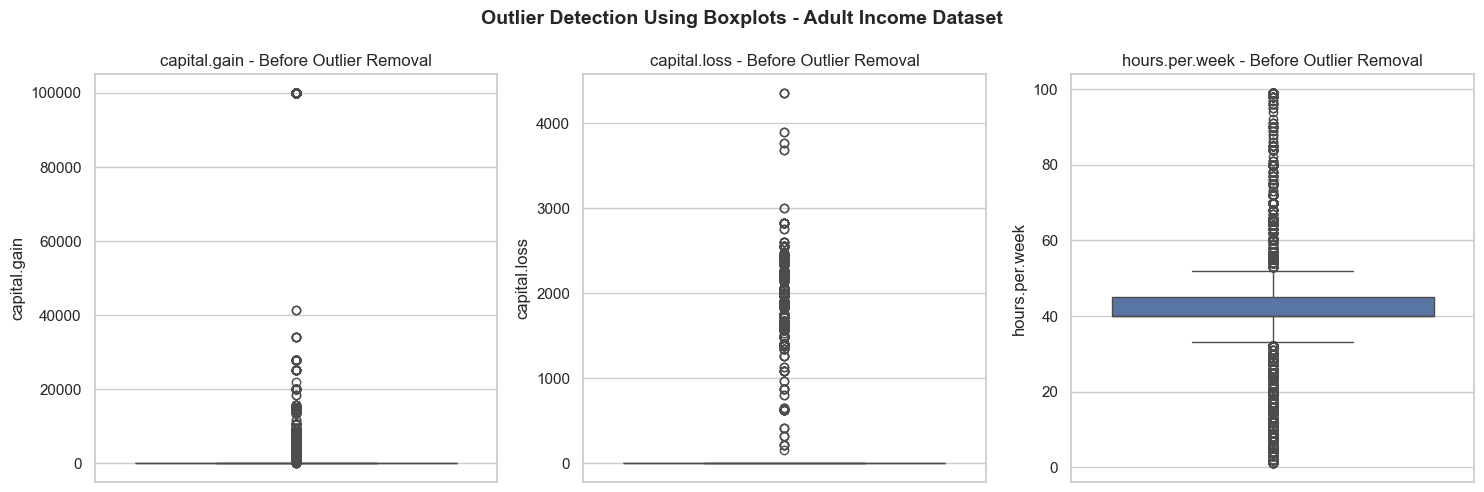

In [4]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(15, 5))

for i, col in enumerate(outlier_cols, start=1):
    ax = plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'{col} - Before Outlier Removal')
    ax.set_ylabel(col)

plt.suptitle('Outlier Detection Using Boxplots - Adult Income Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
FIGURE_BEFORE = OUTPUT_FIGURES_DIR / 'IT25300345_Outlier_Boxplots_Before.png'
plt.savefig(FIGURE_BEFORE, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved figure: {FIGURE_BEFORE.resolve()}')

## 4. Why a standard IQR rule is not used directly

The common IQR rule is:

**Lower bound = Q1 - 1.5 x IQR**  
**Upper bound = Q3 + 1.5 x IQR**

However, in this dataset both `capital.gain` and `capital.loss` have Q1 = 0 and Q3 = 0. Their IQR is therefore 0, which would incorrectly flag every positive value as an outlier.

For `hours.per.week`, the IQR rule would flag a very large share of records. Many of those records can still represent legitimate working patterns. Therefore, the project uses a **conservative 99.5th-percentile upper-tail rule** for these three highly skewed variables.

In [ ]:
# Show what the standard IQR rule would flag - used for justification only
iqr_check = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_iqr = int(((df[col] < lower) | (df[col] > upper)).sum())
    iqr_check.append([col, q1, q3, iqr, lower, upper, n_iqr, n_iqr / len(df) * 100])

iqr_df = pd.DataFrame(iqr_check, columns=[
    'Feature', 'Q1', 'Q3', 'IQR', 'Lower Bound', 'Upper Bound', 'IQR Outliers', 'Percentage (%)'
])
display(iqr_df.round(2))

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,IQR Outliers,Percentage (%)
0,capital.gain,0.0,0.0,0.0,0.0,0.0,2712,8.34
1,capital.loss,0.0,0.0,0.0,0.0,0.0,1519,4.67
2,hours.per.week,40.0,45.0,5.0,32.5,52.5,9002,27.67


## 5. Conservative outlier rule used for this project

We remove only values **above the 99.5th percentile** for each selected feature. This retains 99.5% of observations for each variable while removing only the most extreme upper-tail cases.

This is a practical choice for this dataset because:
1. `capital.gain` and `capital.loss` are zero-inflated.
2. Boxplots show strong right-skew.
3. Standard IQR would remove many potentially valid observations.
4. The upper-tail rule removes a small and explainable proportion of the data rather than a large fraction.

In [ ]:
PERCENTILE = 0.995
thresholds = {}
outlier_counts = {}

# Build the combined outlier mask
outlier_mask = pd.Series(False, index=df.index)

for col in outlier_cols:
    threshold = df[col].quantile(PERCENTILE)
    thresholds[col] = threshold
    col_mask = df[col] > threshold
    outlier_counts[col] = int(col_mask.sum())
    outlier_mask |= col_mask

print('99.5th-percentile thresholds:')
for col, threshold in thresholds.items():
    print(f'  {col}: {threshold:,.2f}')

print('\nOutliers detected per feature:')
for col, count in outlier_counts.items():
    print(f'  {col}: {count:,} ({count / len(df) * 100:.2f}%)')

print(f'\nUnique rows flagged across all three features: {int(outlier_mask.sum()):,}')
print(f'Percentage of dataset flagged: {outlier_mask.mean() * 100:.2f}%')

99.5th-percentile thresholds:
  capital.gain: 34,095.00
  capital.loss: 2,260.88
  hours.per.week: 84.00

Outliers detected per feature:
  capital.gain: 161 (0.49%)
  capital.loss: 163 (0.50%)
  hours.per.week: 159 (0.49%)

Unique rows flagged across all three features: 479
Percentage of dataset flagged: 1.47%


## 6. Remove the detected extreme outliers

Rows containing an extreme upper-tail value in at least one of the three selected variables are removed. The original raw dataset is not overwritten.

In [ ]:
rows_before_outlier_removal = len(df)
df_clean = df.loc[~outlier_mask].copy()
df_clean.reset_index(drop=True, inplace=True)
rows_after_outlier_removal = len(df_clean)
rows_removed = rows_before_outlier_removal - rows_after_outlier_removal

print(f'Rows before outlier removal: {rows_before_outlier_removal:,}')
print(f'Rows removed:               {rows_removed:,}')
print(f'Rows after outlier removal:  {rows_after_outlier_removal:,}')
print(f'Percentage removed:          {rows_removed / rows_before_outlier_removal * 100:.2f}%')

assert rows_removed == int(outlier_mask.sum())
print('Verification passed: removed-row count matches the combined outlier mask.')

Rows before outlier removal: 32,537
Rows removed:               479
Rows after outlier removal:  32,058
Percentage removed:          1.47%
Verification passed: removed-row count matches the combined outlier mask.


## 7. Before vs After boxplots

This comparison is the main visualization to show during the Progress Review viva. After cleaning, the extreme upper-tail values have been removed.

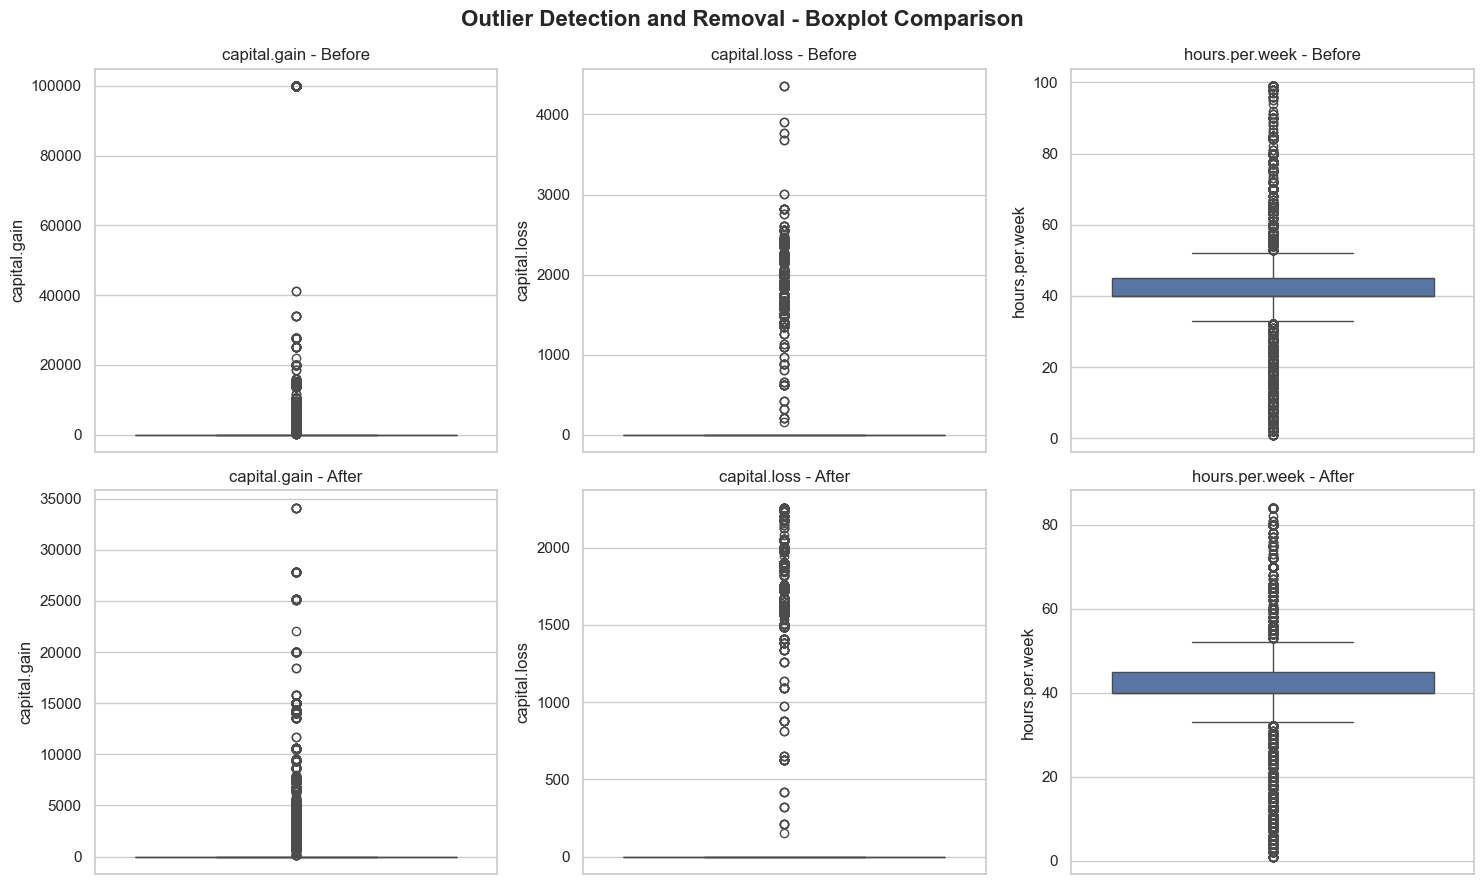

Saved figure: C:\Users\Malan\Downloads\2026-Y2-S1-MLB-B1G1-07\results\eda_visualizations\IT25300345_Outlier_Boxplot_Comparison.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for j, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[0, j])
    axes[0, j].set_title(f'{col} - Before')
    axes[0, j].set_ylabel(col)

    sns.boxplot(y=df_clean[col], ax=axes[1, j])
    axes[1, j].set_title(f'{col} - After')
    axes[1, j].set_ylabel(col)

plt.suptitle('Outlier Detection and Removal - Boxplot Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
FIGURE_COMPARISON = OUTPUT_FIGURES_DIR / 'IT25300345_Outlier_Boxplot_Comparison.png'
plt.savefig(FIGURE_COMPARISON, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved figure: {FIGURE_COMPARISON.resolve()}')

## 8. Check the cleaned numerical data

We compare the main summary statistics before and after removal.

In [5]:
summary_after = df_clean[outlier_cols].describe().T
comparison = pd.DataFrame({
    'Rows Before': df[outlier_cols].count(),
    'Rows After': df_clean[outlier_cols].count(),
    'Mean Before': df[outlier_cols].mean(),
    'Mean After': df_clean[outlier_cols].mean(),
    'Max Before': df[outlier_cols].max(),
    'Max After': df_clean[outlier_cols].max(),
})
display(comparison.round(2))

NameError: name 'df_clean' is not defined